# 03 Correlation Estimation

## Credit Risk Basket CDS Pricing

### Objective

The objective of this notebook is to estimate the dependence structure among the reference entities.

Correlation estimation is a key input for the Gaussian Copula model, as correlated defaults are the primary source of risk in Basket CDS pricing.

Both Pearson and Spearman correlation matrices will be estimated and compared.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 Load Historical Price Data

The adjusted closing prices collected in Notebook 01 are loaded.

These prices will be converted into daily returns before estimating correlations.

In [5]:
prices = pd.read_csv("../Data/bank_prices.csv", index_col=0)

prices.head()

,BAC,C,GS,JPM,MS
Date,,,,,
2023-01-03,30.640949,40.644218,318.011597,123.735207,76.617455
2023-01-04,31.217012,41.691841,319.371124,124.889008,77.448700
2023-01-05,31.152998,41.505405,315.752106,124.861366,76.796211
2023-01-06,31.463890,42.002571,319.720154,127.250633,78.262054
2023-01-09,30.988411,42.206779,324.239227,126.724785,78.333572


## Step 3 Calculate Daily Returns

Correlation should be estimated using returns rather than raw prices.

Daily percentage returns remove long-term price trends and provide a more appropriate measure of co-movement among financial assets.

The daily return is calculated as:

Daily Return = (Today's Price − Yesterday's Price) / Yesterday's Price

In [6]:
returns = prices.pct_change().dropna()

returns.head()

,BAC,C,GS,JPM,MS
Date,,,,,
2023-01-04,0.018800,0.025775,0.004275,0.009325,0.010849
2023-01-05,-0.002051,-0.004472,-0.011332,-0.000221,-0.008425
2023-01-06,0.009980,0.011978,0.012567,0.019135,0.019087
2023-01-09,-0.015112,0.004862,0.014134,-0.004132,0.000914
2023-01-10,0.006787,0.013673,0.012351,0.008954,0.014605


## Step 4 Explore Daily Returns

Before estimating correlations, summary statistics are reviewed to understand the distribution of daily returns.

In [7]:
returns.describe()

,BAC,C,GS,JPM,MS
count,501.000000,501.000000,501.000000,501.000000,501.000000
mean,0.000775,0.001155,0.001237,0.001347,0.001045
std,0.015669,0.016304,0.015717,0.013963,0.016387
min,-0.062039,-0.074473,-0.064385,-0.064678,-0.067845
25%,-0.008186,-0.007825,-0.007392,-0.005230,-0.007410
50%,0.000000,0.001029,0.000710,0.001895,0.000951
75%,0.008678,0.010210,0.009725,0.008124,0.009569
max,0.084288,0.084184,0.130978,0.115445,0.116119


## Step 5 Estimate Pearson Correlation

Pearson correlation measures the strength of the linear relationship between two variables.

It is widely used in finance and serves as the standard correlation input for Gaussian Copula models.

In [8]:
pearson_corr = returns.corr(method="pearson")

pearson_corr

,BAC,C,GS,JPM,MS
BAC,1.000000,0.785958,0.714061,0.723304,0.705794
C,0.785958,1.000000,0.684346,0.703900,0.663203
GS,0.714061,0.684346,1.000000,0.687839,0.732027
JPM,0.723304,0.703900,0.687839,1.000000,0.615057
MS,0.705794,0.663203,0.732027,0.615057,1.000000


## Step 6 Visualize Pearson Correlation Matrix

A heatmap provides a visual representation of the strength of the linear relationships among the five banks.

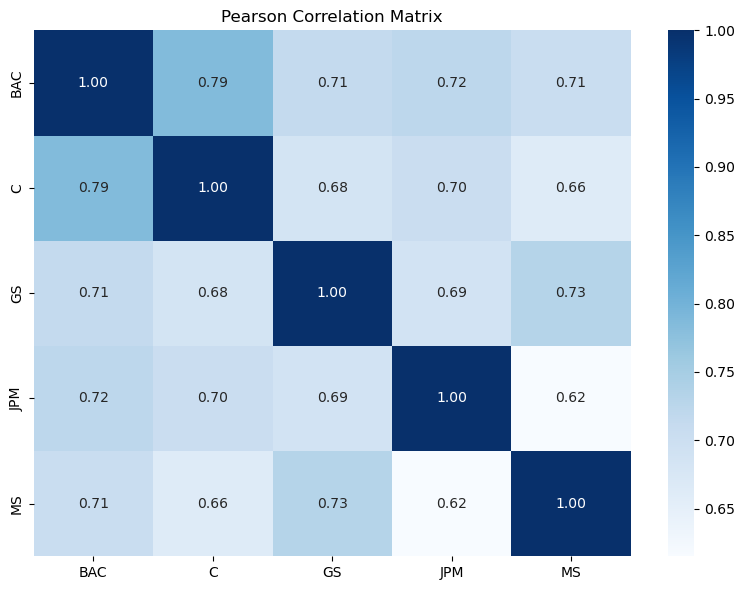

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Pearson Correlation Matrix")

plt.tight_layout()



plt.show()

## Step 7 Estimate Spearman Correlation

Spearman correlation measures the monotonic relationship between variables using ranked observations.

Unlike Pearson correlation, it is less sensitive to extreme values and does not assume linear dependence.

In [11]:
spearman_corr = returns.corr(method="spearman")

spearman_corr

,BAC,C,GS,JPM,MS
BAC,1.000000,0.754743,0.688323,0.730128,0.711294
C,0.754743,1.000000,0.662723,0.672322,0.659737
GS,0.688323,0.662723,1.000000,0.654650,0.768023
JPM,0.730128,0.672322,0.654650,1.000000,0.628184
MS,0.711294,0.659737,0.768023,0.628184,1.000000


## Step 8 Visualize Spearman Correlation Matrix

The Spearman correlation matrix is visualized to compare rank-based dependence with linear dependence.

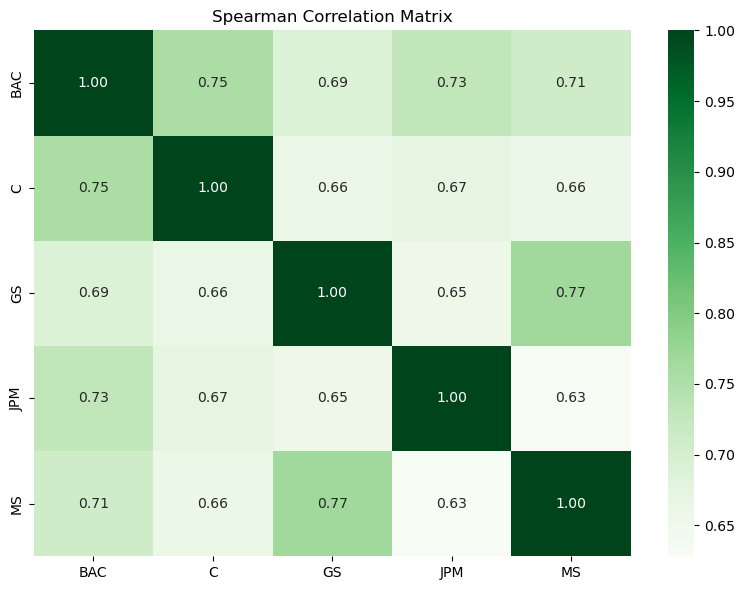

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="Greens",
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix")

plt.tight_layout()



plt.show()

# Business Interpretation

The estimated correlation matrices indicate that the selected banks exhibit positive dependence, reflecting their exposure to common macroeconomic and financial market conditions.

Higher correlations imply that defaults are more likely to occur together during periods of financial stress.

Therefore, correlation estimation plays a critical role in Basket CDS pricing, especially for higher-order default products.

# Summary

In this notebook:

- Loaded historical price data
- Calculated daily returns
- Estimated Pearson correlation
- Estimated Spearman correlation
- Visualized both correlation matrices

The estimated correlation matrix will be used as the dependence structure for the Gaussian Copula model in the next notebook.

array([[<Axes: title={'center': 'BAC'}>, <Axes: title={'center': 'C'}>],
       [<Axes: title={'center': 'GS'}>, <Axes: title={'center': 'JPM'}>],
       [<Axes: title={'center': 'MS'}>, <Axes: >]], dtype=object)

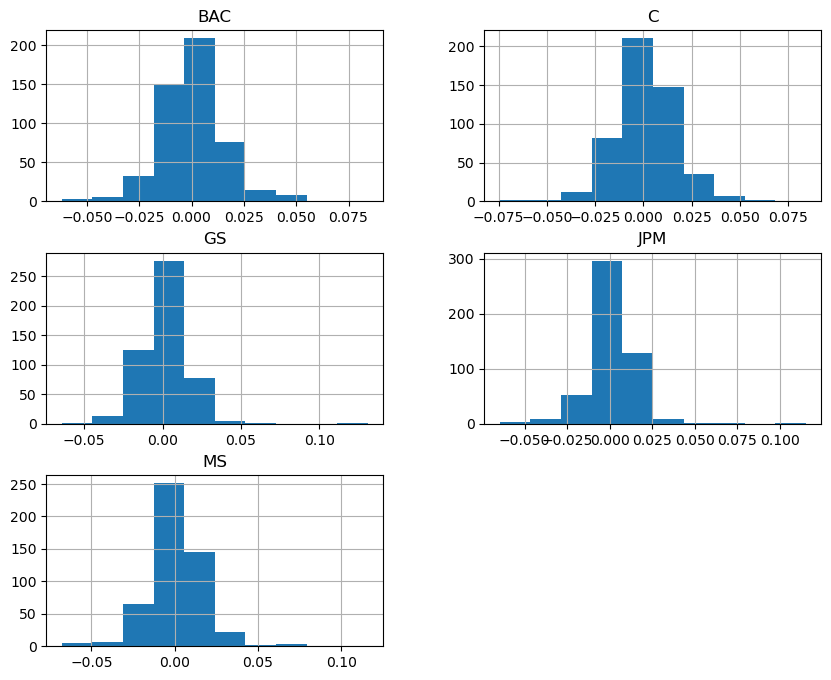

In [14]:
returns.hist(figsize=(10,8))